# MIMO‑OFDM Inspired Lead‑Lag Detection with MUSIC

This notebook demonstrates the use of the MUSIC algorithm to estimate the propagation delay (lead‑lag) between correlated assets.
We treat the assets as an antenna array and the returns as the received signal. MUSIC resolves sub‑sample delays.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from data_loader import fetch_asset_data, compute_returns
from music_latency import MUSICDelayEstimator
import visualization as viz

## 1. Load Data

We'll fetch 1‑minute data for SPY, QQQ, AAPL, MSFT. These are highly correlated.
If you prefer a Kaggle dataset, replace with `load_from_csv('path.csv')`.

In [4]:
from data_loader import load_from_csv

# Load the synthetic data we generated earlier
prices = load_from_csv('../data/synthetic_assets.csv')
returns = compute_returns(prices)

# Extract symbols from the columns for the visualization step later
symbols = prices.columns.tolist() 

returns.head()

,SPY,QQQ,AAPL,MSFT
timestamp,,,,
2025-01-01 09:31:00,0.000300,-0.00065,-0.001001,-0.000560
2025-01-01 09:32:00,0.000699,0.00020,0.000400,0.000560
2025-01-01 09:33:00,0.001197,0.00035,0.001400,0.000720
2025-01-01 09:34:00,0.000100,-0.00110,0.000133,-0.000800
2025-01-01 09:35:00,0.000000,0.00075,0.000000,0.000919


## 2. Visualize Cross‑Correlation

Before using MUSIC, look at standard cross‑correlation to see rough lags.

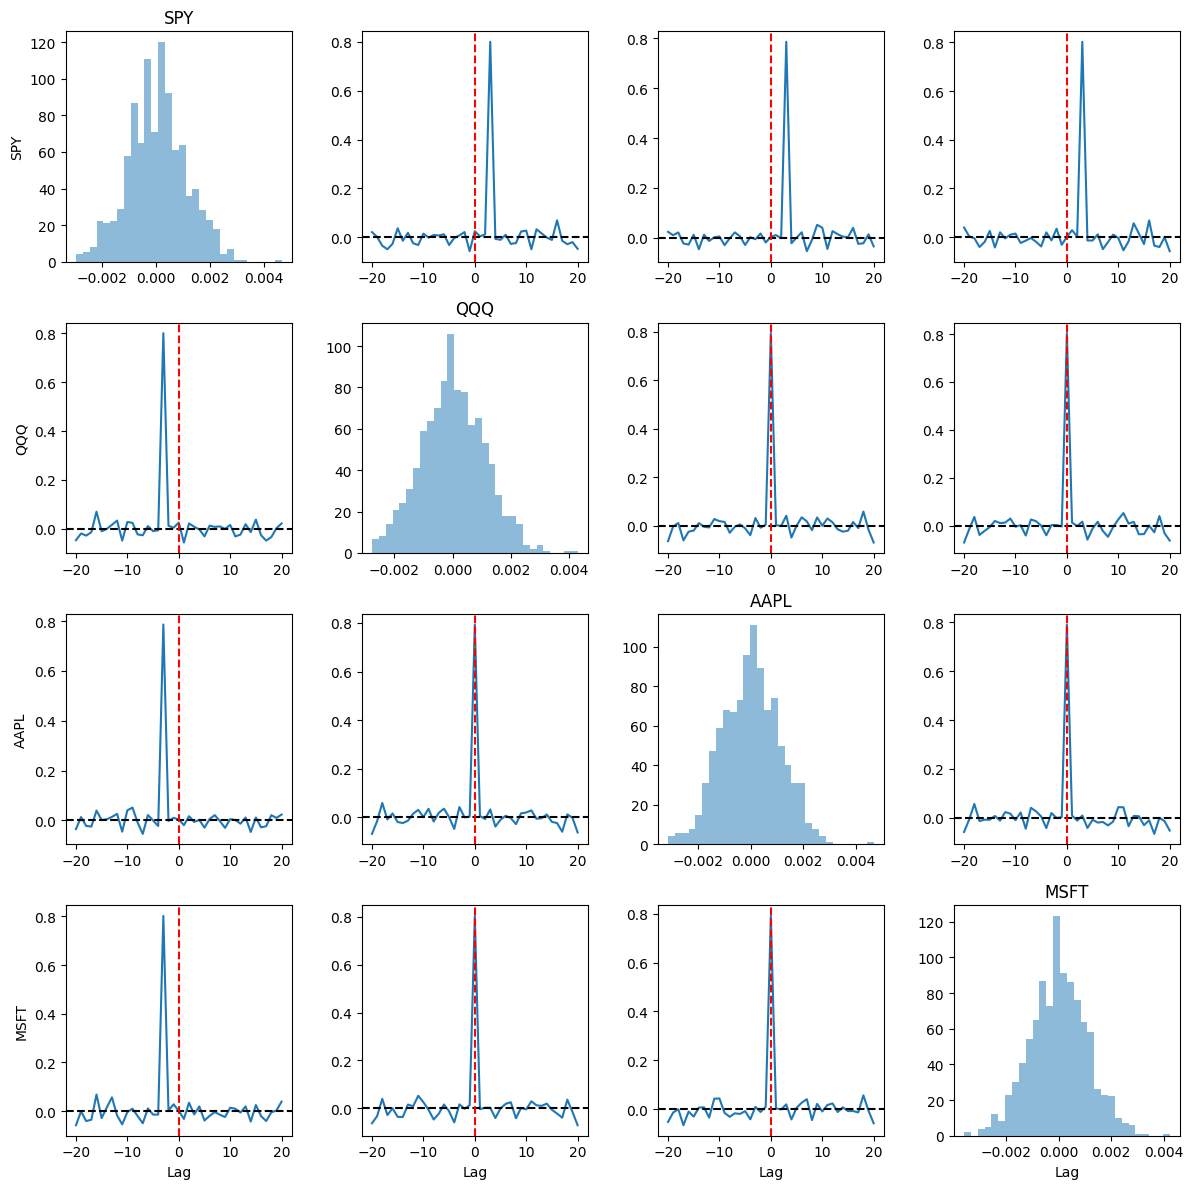

In [5]:
viz.plot_cross_correlation(returns, symbols, max_lag=20)

## 3. Apply MUSIC to Estimate Delay

We'll treat SPY as the reference (delay 0) and estimate the delay of QQQ, AAPL, MSFT relative to SPY.
In our simplified model, we assume all other assets have the same relative delay (i.e., the news propagates with a common lag).

In [ ]:
X = returns.values  # shape (n_samples, n_assets)

# Initialize MUSIC with one source (the common signal)
music = MUSICDelayEstimator(n_sources=1)
music.fit(X)

# Candidate delays in seconds (our sampling interval is 1 minute = 60 seconds)
delays = np.linspace(-5*60, 5*60, 201)  # -5 minutes to +5 minutes
spectrum = music.compute_spectrum(delays, fs=1/60, f0=1.0)

viz.plot_music_spectrum(delays, spectrum)

# Find peak
peak_idx = np.argmax(spectrum)
estimated_delay = delays[peak_idx]
print(f"Estimated delay (other assets relative to SPY): {estimated_delay:.2f} seconds")

## 4. Interpretation

A positive delay means the other assets lag behind SPY; negative means they lead.
The MUSIC spectrum gives a sharp peak, often much sharper than the cross‑correlation, thanks to super‑resolution.